# 웹툰 탐색적 분석

### **데이터 분석의 전제**

웹툰의 데이터는 영화 데이터와 다릅니다. 영화는 트렌드성과 대중성의 지표가 따로 있었지만, 웹툰은 하나의 지표밖에 없습니다.

웹툰 데이터는 웹툰 정보를 크롤링 한 것이 아니라, 알라딘 API를 사용해서 유명한 웹툰 데이터를 가져온 것입니다. 알라딘 사이트에서 다음과 같은 기준으로 점수를 메긴 지표가 있기에, 이 지표를 사용하여 분석과 추천 로직에 활용하겠습니다.

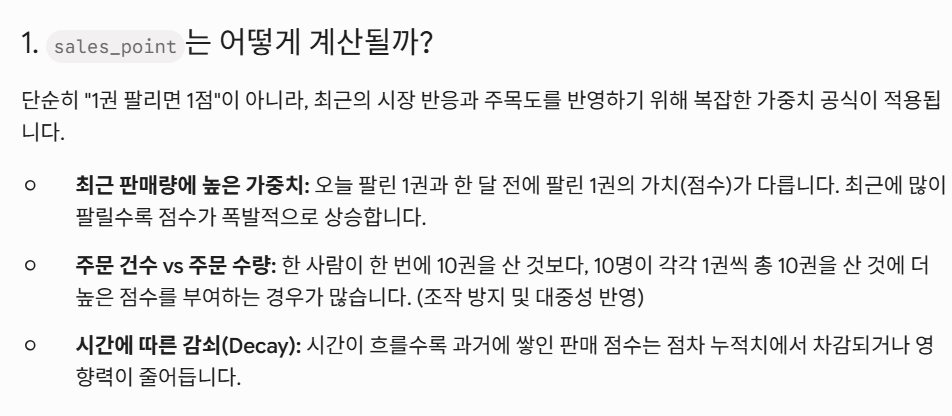

## 1. 기본적인 분포 및 통계 분석

In [2]:
import pandas as pd

df = pd.read_csv('webtoon.csv')
df.head()

,series_title,genres,author,sales_point,description,publisher,pub_date,cover_url,link,original_title,mood_kor,mood_eng
0,전지적 독자 시점,판타지,"슬리피-C (지은이), 싱숑 (원작), UMI (각색)",18910,낙원의 멸망을 딛고 비상한 키메라 드래곤. 그리고 일행 앞에 주어진 새로운 시련. ...,에이템포미디어,2026-05-22,https://image.aladin.co.kr/product/39372/72/co...,https://www.aladin.co.kr/shop/wproduct.aspx?It...,총 22권 포함 (대표작: 전지적 독자 시점 19 - 초판한정: 캐릭터 카드 1종 ...,역동적인 액션,dynamic and colorful action
1,별정직 공무원,SF/미래,"권소라, 서재원 (지은이), ch (그림)",15200,"우주의 사고 후, 사직서를 내고 집에 틀어박힌 마루 앞에 갑자기 나타난 정일두 국장...",학산문화사(만화),2026-05-19,https://image.aladin.co.kr/product/39251/86/co...,https://www.aladin.co.kr/shop/wproduct.aspx?It...,총 8권 포함 (대표작: 별정직 공무원 4 (특별판) - 아크릴 스탠드 + 유니폼 ...,역동적인 액션,dynamic and colorful action
2,엄마를 만나러 가는 길,코미디/힐링,고먕 (지은이),14060,엄마를 찾아 나선 모리의 여정을 담은 네이버웹툰 &lt;엄마를 만나러 가는 길&gt...,네이버웹툰,2026-06-22,https://image.aladin.co.kr/product/39194/35/co...,https://www.aladin.co.kr/shop/wproduct.aspx?It...,총 4권 포함 (대표작: 엄마를 만나러 가는 길 - 모리의 스티커북 /초판 한정 부...,따뜻하고 포근한 힐링,warm and cozy healing
3,오무라이스 잼잼,코미디/힐링,조경규 (지은이),13708,《오무라이스잼잼》 16권이 봄꽃과 함께 독자들을 찾아왔다. 16권에는 어느새 수험생...,송송책방,2026-04-01,https://image.aladin.co.kr/product/38900/98/co...,https://www.aladin.co.kr/shop/wproduct.aspx?It...,총 21권 포함 (대표작: 오무라이스 잼잼 16),빈티지하고 고전적인 화풍,vintage and retro style
4,내가 키운 S급들,판타지,"비완 (지은이), 근서 (원작), seri (각색)",8723,&lt;사망한 한유현의 스킬과 능력치가 두 배로 전이됩니다.&gt; 그리고 힘과 함...,JAYPLEMEDIA,2025-12-22,https://image.aladin.co.kr/product/37726/40/co...,https://www.aladin.co.kr/shop/wproduct.aspx?It...,총 1권 포함 (대표작: 내가 키운 S급들 1~2 + 굿즈 패키지 세트),역동적인 액션,dynamic and colorful action


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   series_title    297 non-null    object
 1   genres          297 non-null    object
 2   author          297 non-null    object
 3   sales_point     297 non-null    int64 
 4   description     297 non-null    object
 5   publisher       297 non-null    object
 6   pub_date        297 non-null    object
 7   cover_url       297 non-null    object
 8   link            297 non-null    object
 9   original_title  297 non-null    object
 10  mood_kor        297 non-null    object
 11  mood_eng        297 non-null    object
dtypes: int64(1), object(11)
memory usage: 28.0+ KB


결측값은 존재하지 않음

In [4]:
df.describe()

,sales_point
count,297.000000
mean,1553.171717
std,2217.017956
min,0.000000
25%,390.000000
50%,820.000000
75%,1883.000000
max,18910.000000


### 1.2 Salespoint 분석

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
=== [상위 1% 초대박 이상치 작품 (기준점: 13,722.08 이상)] ===
   series_title                          author  genres  sales_point
0     전지적 독자 시점  슬리피-C (지은이), 싱숑 (원작), UMI (각색)     판타지        18910
1       별정직 공무원         권소라, 서재원 (지은이), ch (그림)   SF/미래        15200
2  엄마를 만나러 가는 길                        고먕 (지은이)  코미디/힐링        14060


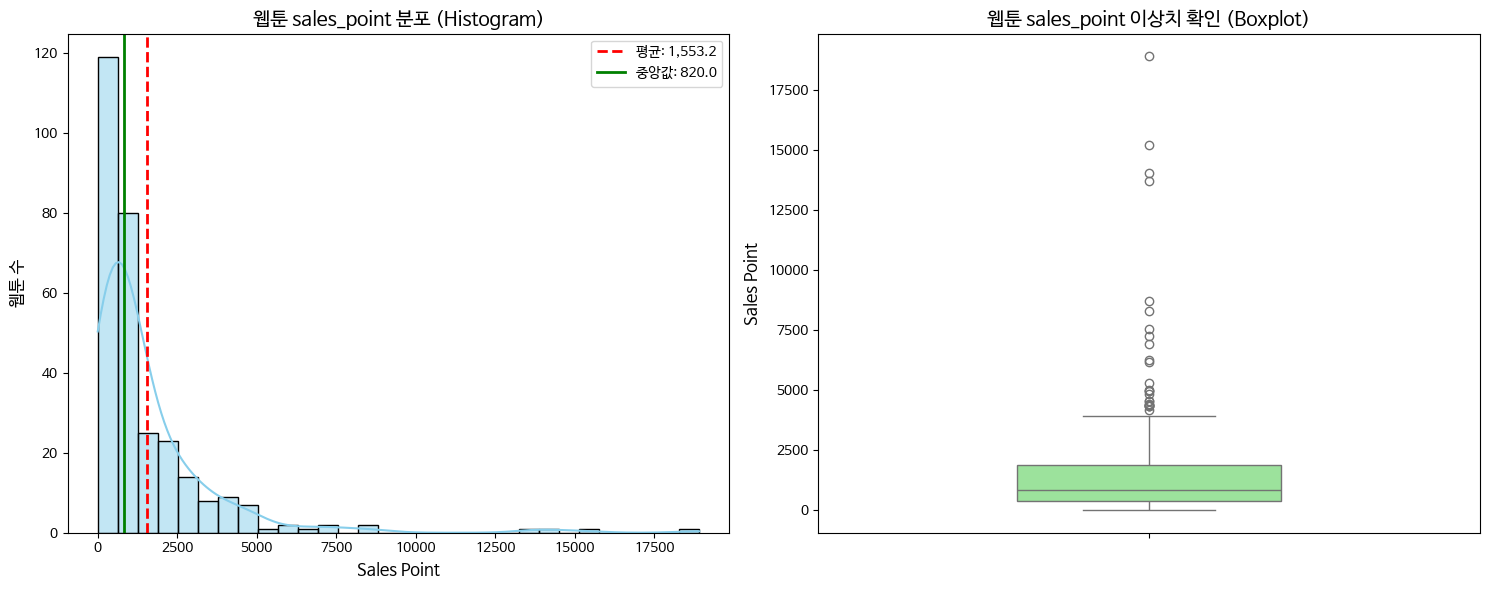

In [5]:
# 1. 한글 폰트 설치 및 폰트 캐시 리빌드 (코랩 환경용)
!apt-get update -qq
!apt-get install fonts-nanum -qq

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings

# 모든 경고 메시지 무시 설정
warnings.filterwarnings('ignore')

# 2. 설치된 나눔 폰트를 matplotlib 폰트 매니저에 등록
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 3. 기본 기술통계량 및 상위 1% 기준 계산
desc = df['sales_point'].describe()
mean_val = desc['mean']
median_val = desc['50%']
quantile_99 = df['sales_point'].quantile(0.99)
skewness = df['sales_point'].skew()

# 상위 1% 초메가 히트작 추출
outliers = df[df['sales_point'] >= quantile_99].sort_values(by='sales_point', ascending=False)
print(f"=== [상위 1% 초대박 이상치 작품 (기준점: {quantile_99:,.2f} 이상)] ===")
print(outliers[['series_title', 'author', 'genres', 'sales_point']])
print("=" * 50)


# 4. 데이터 시각화 진행
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# [왼쪽 그래프] 히스토그램 (Histogram)
sns.histplot(data=df, x='sales_point', bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('웹툰 sales_point 분포 (Histogram)', fontsize=14)
axes[0].set_xlabel('Sales Point', fontsize=12)
axes[0].set_ylabel('웹툰 수', fontsize=12)

# 평균값과 중앙값 점선 표시
axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"평균: {mean_val:,.1f}")
axes[0].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f"중앙값: {median_val:,.1f}")
axes[0].legend()

# [오른쪽 그래프] 박스플롯 (Boxplot)
# 가로형(x=) 보다는 세로형(y=)이 이상치 점들을 위로 길게 보기에 더 좋아서 y축으로 설정했습니다.
sns.boxplot(data=df, y='sales_point', ax=axes[1], color='lightgreen', width=0.4)
axes[1].set_title('웹툰 sales_point 이상치 확인 (Boxplot)', fontsize=14)
axes[1].set_ylabel('Sales Point', fontsize=12)

# 그래프 레이아웃 정렬 및 출력
plt.tight_layout()
plt.show()

### 1.3 장르, 무드 분석

=== [1. 장르별 평균 Sales Point 상위 10] ===
            count         mean  median
genre_list                            
SF/미래           7  3383.000000   924.0
판타지            35  2218.342857   922.0
코미디/힐링         38  1927.131579   697.0
음악/스포츠         13  1890.230769  1679.0
무협/사극           7  1421.142857   750.0
드라마/성장        173  1332.566474   777.0
공포/호러          11  1254.818182   681.0
스릴러/범죄         26  1115.923077   813.5
로맨스            37  1051.810811   667.0
액션              3   508.000000   666.0
------------------------------------------------------------
=== [2. 무드(Mood)별 평균 Sales Point 상위 10] ===
               count         mean  median
mood_kor                                 
역동적인 액션           51  2172.784314   730.0
따뜻하고 포근한 힐링       38  1799.921053  1109.5
어둡고 거친 스릴러        11  1784.545455  1900.0
빈티지하고 고전적인 화풍     55  1452.163636   465.0
화려하고 우아한 판타지      70  1362.585714   788.0
밝고 화사한 로맨스        61  1235.754098   937.0
깔끔하고 현대적인 일상      11  1074.727273   573.0


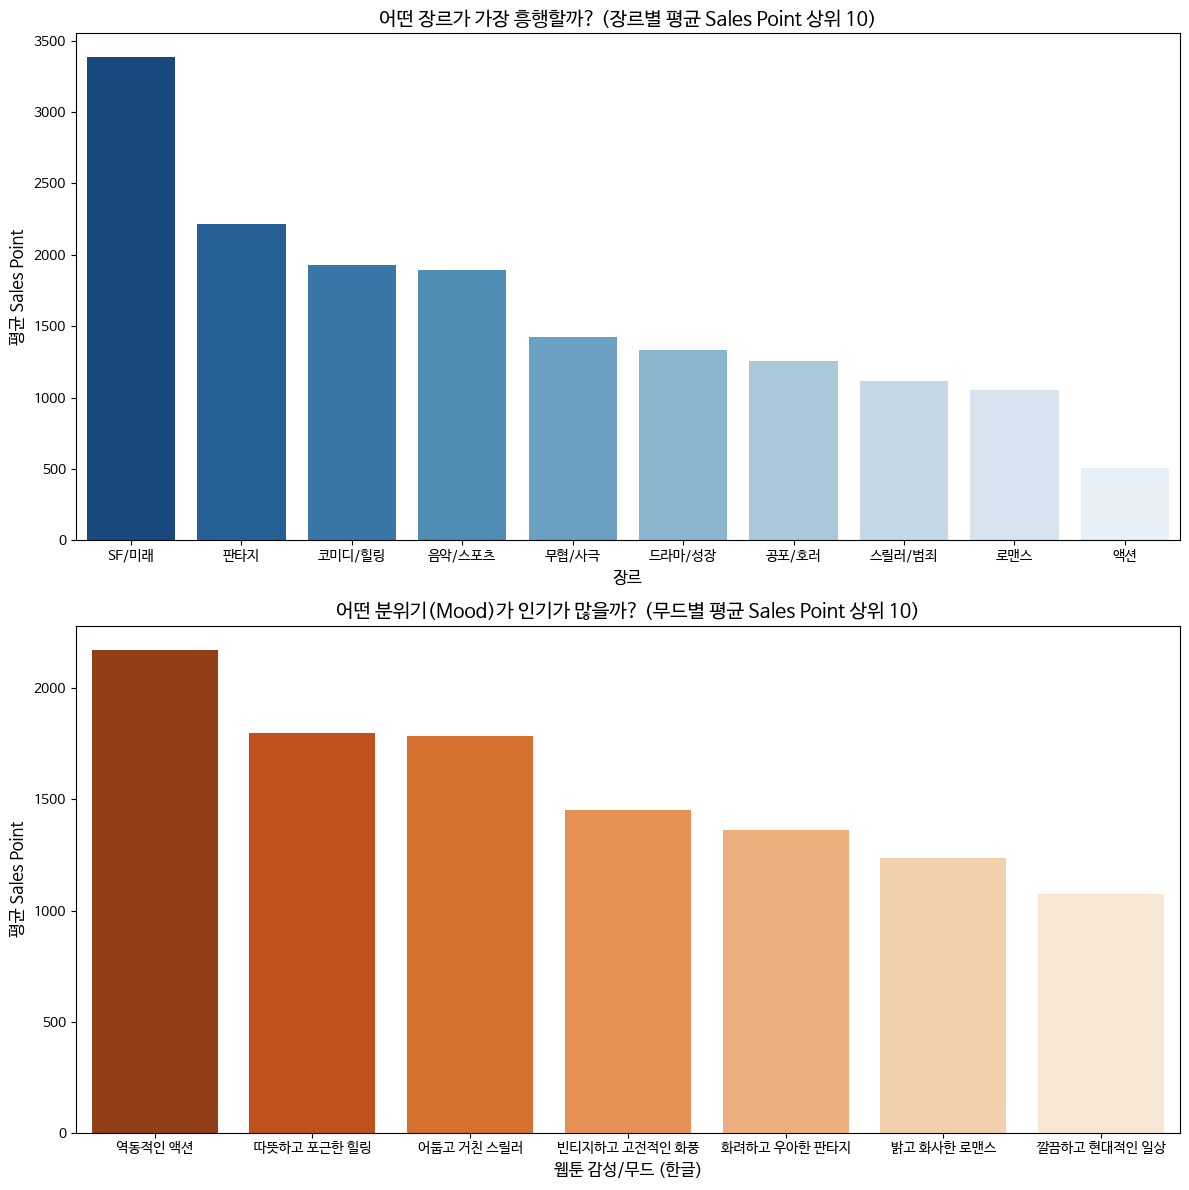

In [6]:
df['genre_list'] = df['genres'].str.replace(' ', '').str.split(',')

# 리스트로 된 장르를 개별 행으로 쪼갭니다. (Explode)
df_genre_exploded = df.explode('genre_list')

print("=== [1. 장르별 평균 Sales Point 상위 10] ===")
genre_stats = df_genre_exploded.groupby('genre_list')['sales_point'].agg(['count', 'mean', 'median']).sort_values(by='mean', ascending=False)
print(genre_stats.head(10))
print("-" * 60)

print("=== [2. 무드(Mood)별 평균 Sales Point 상위 10] ===")
mood_stats = df.groupby('mood_kor')['sales_point'].agg(['count', 'mean', 'median']).sort_values(by='mean', ascending=False)
print(mood_stats.head(10))
print("=" * 60)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 12))

top_genres = genre_stats[genre_stats['count'] >= 3].index[:10]
sns.barplot(
    data=df_genre_exploded[df_genre_exploded['genre_list'].isin(top_genres)],
    x='genre_list', y='sales_point',
    ax=axes[0], palette='Blues_r', ci=None, order=top_genres
)
axes[0].set_title('어떤 장르가 가장 흥행할까? (장르별 평균 Sales Point 상위 10)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('장르', fontsize=12)
axes[0].set_ylabel('평균 Sales Point', fontsize=12)

top_moods = mood_stats[mood_stats['count'] >= 3].index[:10]
sns.barplot(
    data=df[df['mood_kor'].isin(top_moods)],
    x='mood_kor', y='sales_point',
    ax=axes[1], palette='Oranges_r', ci=None, order=top_moods
)
axes[1].set_title('어떤 분위기(Mood)가 인기가 많을까? (무드별 평균 Sales Point 상위 10)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('웹툰 감성/무드 (한글)', fontsize=12)
axes[1].set_ylabel('평균 Sales Point', fontsize=12)

plt.tight_layout()
plt.show()

[하드코어 대작 트랙] SF/미래 또는 판타지 장르 + 역동적인 액션이나 어둡고 거친 스릴러 무드 조합 (예: 아포칼립스 액션물, 하드보일드 디스토피아)

[소프트 가성비 트랙] 코미디/힐링 장르 + 따뜻하고 포근한 힐링 무드 조합 (예: 일상 만화, 힐링 판타지 동물물)

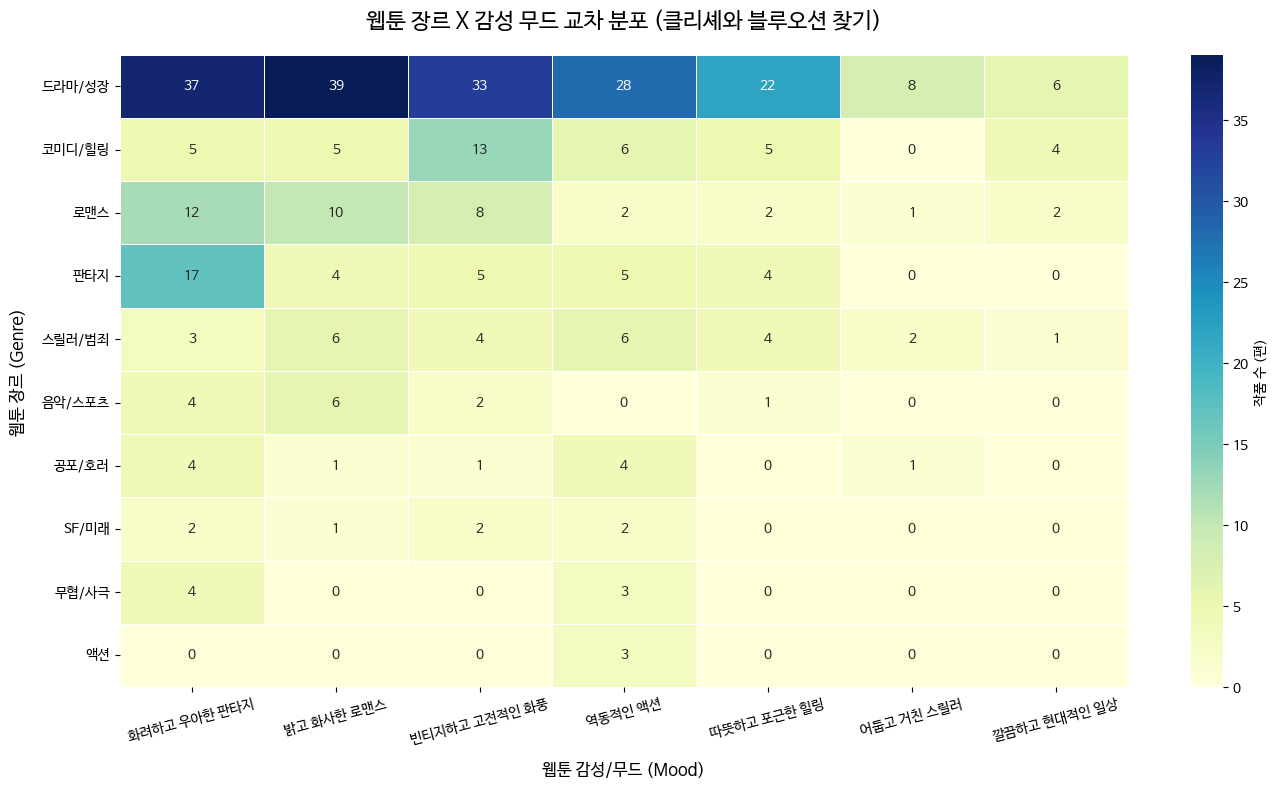

In [7]:
top_genres = df_genre_exploded['genre_list'].value_counts().head(10).index
top_moods = df['mood_kor'].value_counts().head(7).index

df_filtered = df_genre_exploded[
    (df_genre_exploded['genre_list'].isin(top_genres)) &
    (df_genre_exploded['mood_kor'].isin(top_moods))
]

# 1. 장르와 무드의 교차 빈도표(Crosstab) 생성
cross_tab = pd.crosstab(
    index=df_filtered['genre_list'],
    columns=df_filtered['mood_kor'],
)

# 데이터 가독성을 위해 상위 장르/무드 순서로 재정렬
cross_tab = cross_tab.loc[top_genres, top_moods]


# 2. 히트맵(Heatmap) 시각화
plt.figure(figsize=(14, 8))
sns.heatmap(
    cross_tab,
    annot=True,      # 격자 내부에 실제 숫자 표시
    fmt='d',         # 정수형(Integer) 포맷 설정
    cmap='YlGnBu',   # 노란색 -> 녹색 -> 파란색으로 짙어지는 컬러맵
    linewidths=0.5,  # 셀 사이의 간격 선
    cbar_kws={'label': '작품 수 (편)'}
)

plt.title('웹툰 장르 X 감성 무드 교차 분포 (클리셰와 블루오션 찾기)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('웹툰 감성/무드 (Mood)', fontsize=12, labelpad=10)
plt.ylabel('웹툰 장르 (Genre)', fontsize=12, labelpad=10)
plt.xticks(rotation=15) # X축 글자 살짝 기울이기
plt.tight_layout()
plt.show()

이 플랫폼의 데이터는 "흔한 드라마물로 승부 보지 말고, 공급이 적은 SF/미래 대작을 노리거나, 수요는 폭발하는데 공급이 고작 3편뿐인 정통 액션 X 역동적 무드 조합을 공략해야 초대박(이상치 영역)을 터뜨릴 수 있다"는 것을 숫자로 증명하고 있습니다.

## **2. 시계열 및 트렌드 분석 (Temporal Analysis)**

### 2.1 연도별 웹툰 제작 및 흥행 트렌드

=== 연도별 웹툰 제작 수 및 흥행 지표 요약 ===
 pub_year  count        mean  median
     2011      2  752.000000   752.0
     2012      1 1679.000000  1679.0
     2014      1  242.000000   242.0
     2015      6 1266.166667   868.0
     2016      6 1055.833333   510.0
     2017      3 1504.333333  1896.0
     2018      6 1283.333333   581.0
     2019      3  637.333333   559.0
     2020     15 1235.533333   903.0
     2021     14  927.571429  1002.5
     2022     24 1386.583333   516.5
     2023     21 1126.857143   381.0
     2024     37  813.270270   444.0
     2025     57 1644.578947   907.0
     2026    101 2153.633663  1140.0


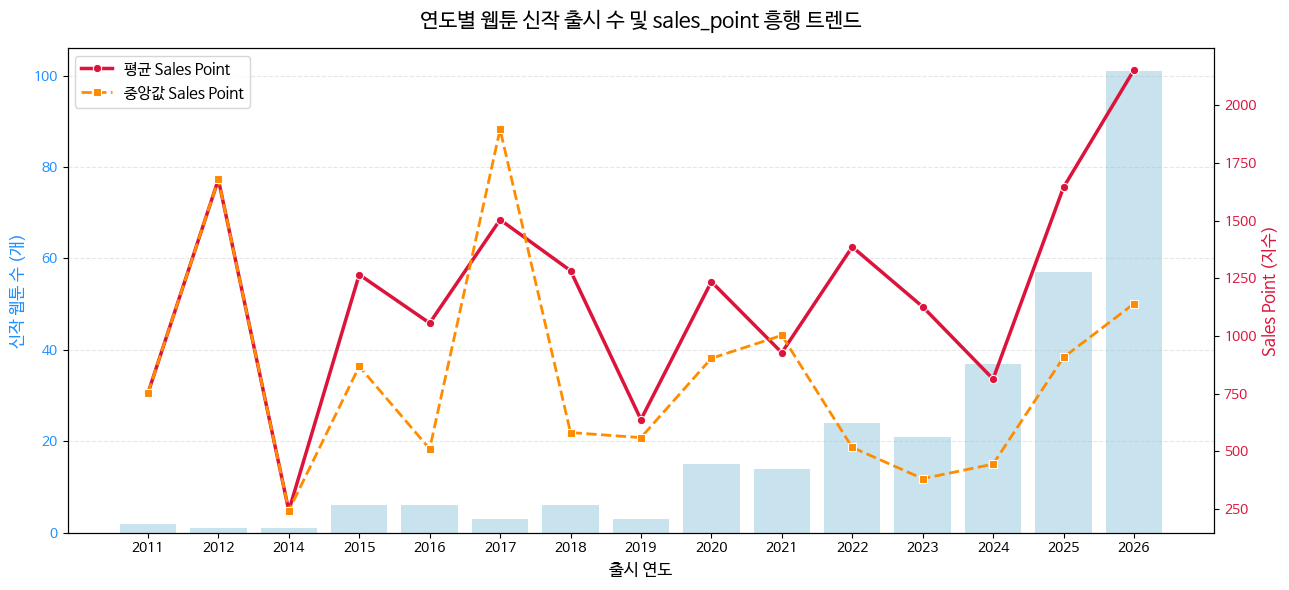

In [8]:
df['pub_date'] = pd.to_datetime(df['pub_date'], errors='coerce')
df['pub_year'] = df['pub_date'].dt.year

# 날짜 데이터가 없는 행 제외 후 정수형(int) 변환
df_cleaned = df.dropna(subset=['pub_year'])
df_cleaned['pub_year'] = df_cleaned['pub_year'].astype(int)

# 연도순으로 정렬하기 위해 고유 연도 추출
unique_years = sorted(df_cleaned['pub_year'].unique())

# 3. 연도별 핵심 통계량 계산 (작품 수, 평균, 중앙값)
yearly_summary = df_cleaned.groupby('pub_year')['sales_point'].agg(
    count='count',
    mean='mean',
    median='median'
).reset_index()

print("=== 연도별 웹툰 제작 수 및 흥행 지표 요약 ===")
print(yearly_summary.to_string(index=False))
print("=" * 45)


# 4. 이중 축(Dual Axis)을 활용한 시각화
fig, ax1 = plt.subplots(figsize=(13, 6))

# [축 1] 연도별 신작 출시 수 -> 바 차트 (Bar Chart)
sns.barplot(
    data=yearly_summary,
    x='pub_year',
    y='count',
    alpha=0.5,
    color='skyblue',
    ax=ax1
)
ax1.set_title('연도별 웹툰 신작 출시 수 및 sales_point 흥행 트렌드', fontsize=15, pad=15)
ax1.set_xlabel('출시 연도', fontsize=12)
ax1.set_ylabel('신작 웹툰 수 (개)', color='dodgerblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='dodgerblue')
ax1.grid(True, axis='y', alpha=0.3, linestyle='--')

# [축 2] 연도별 sales_point 추이 -> 라인 차트 (Line Chart)
# ax1과 x축을 공유하는 이중 축 생성
ax2 = ax1.twinx()

# ⚠️ seaborn lineplot에서 x축이 범주형(bar) 스케일과 어긋나는 것을 방지하기 위해
# x축 위치를 0, 1, 2... 인덱스 순서로 매핑하여 플로팅합니다.
x_indices = range(len(yearly_summary))

sns.lineplot(
    x=x_indices,
    y=yearly_summary['mean'],
    color='crimson',
    marker='o',
    linewidth=2.5,
    label='평균 Sales Point',
    ax=ax2
)
sns.lineplot(
    x=x_indices,
    y=yearly_summary['median'],
    color='darkorange',
    marker='s',
    linewidth=2,
    linestyle='--',
    label='중앙값 Sales Point',
    ax=ax2
)

ax2.set_ylabel('Sales Point (지수)', color='crimson', fontsize=12)
ax2.tick_params(axis='y', labelcolor='crimson')

# 이중 축 사용 시 범례가 꼬이지 않도록 통합 단일 배치
ax2.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

단순히 작품수가 많아서, 2025, 2026 지표가 좋은 것일수도 있으니,
mean값을 median으로 나누어, 몇개의 작품이 이끌었는지, 아니면 해당 연도의 작품이 고루 좋은지 분석할 수 있음

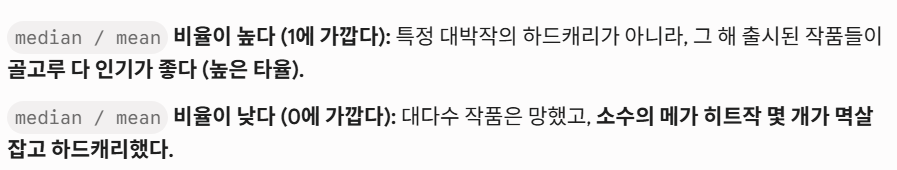

=== 비율 지표가 추가된 연도별 요약 ===
 pub_year  count        mean  median  skew_ratio
     2011      2  752.000000   752.0    1.000000
     2012      1 1679.000000  1679.0    1.000000
     2014      1  242.000000   242.0    1.000000
     2015      6 1266.166667   868.0    0.685534
     2016      6 1055.833333   510.0    0.483031
     2017      3 1504.333333  1896.0    1.260359
     2018      6 1283.333333   581.0    0.452727
     2019      3  637.333333   559.0    0.877092
     2020     15 1235.533333   903.0    0.730858
     2021     14  927.571429  1002.5    1.080779
     2022     24 1386.583333   516.5    0.372498
     2023     21 1126.857143   381.0    0.338109
     2024     37  813.270270   444.0    0.545944
     2025     57 1644.578947   907.0    0.551509
     2026    101 2153.633663  1140.0    0.529338


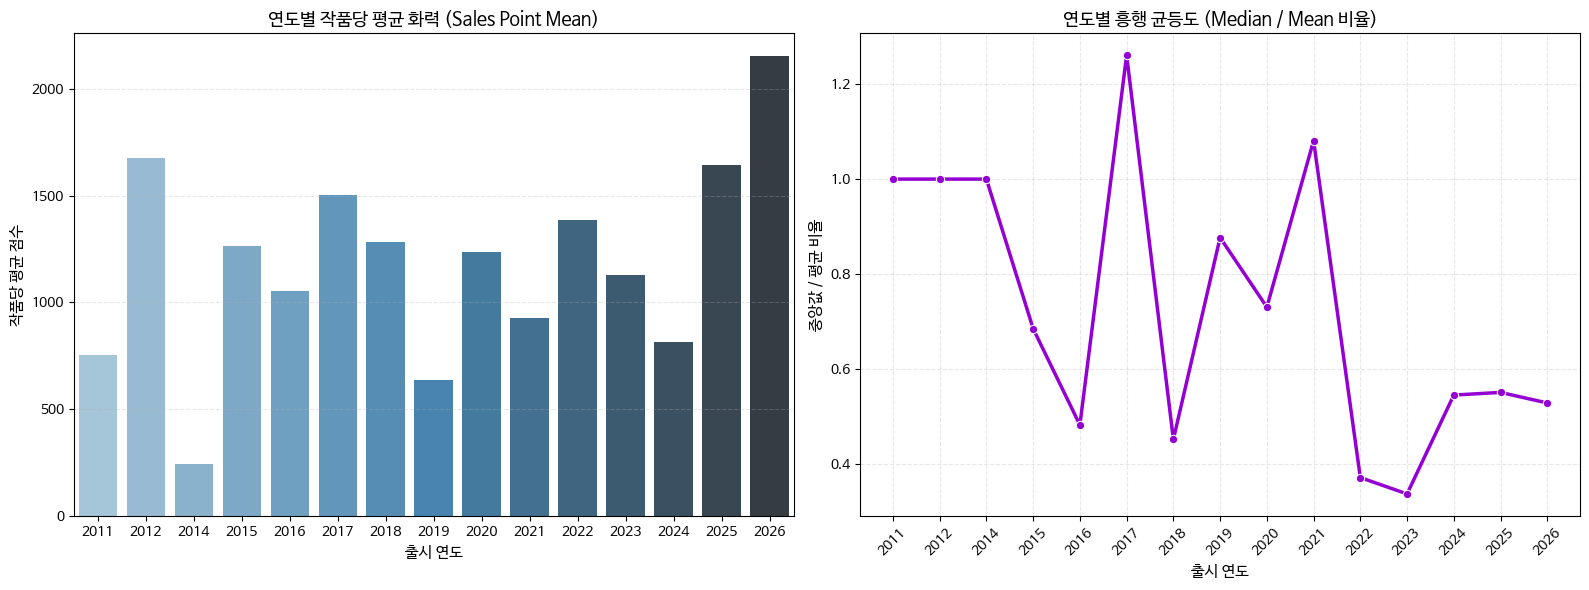

In [9]:
yearly_summary['skew_ratio'] = yearly_summary['median'] / yearly_summary['mean']

print("=== 비율 지표가 추가된 연도별 요약 ===")
print(yearly_summary[['pub_year', 'count', 'mean', 'median', 'skew_ratio']].to_string(index=False))
print("=" * 60)

# 3. 비율 기반 시각화 (작품 수의 착시를 지운 진짜 트렌드)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# [왼쪽] 연도별 작품당 평균 Sales Point (작품 수 착시 제거)
sns.barplot(
    data=yearly_summary,
    x='pub_year',
    y='mean',
    palette='Blues_d',
    ax=axes[0]
)
axes[0].set_title('연도별 작품당 평균 화력 (Sales Point Mean)', fontsize=13)
axes[0].set_xlabel('출시 연도', fontsize=11)
axes[0].set_ylabel('작품당 평균 점수', fontsize=11)
axes[0].grid(True, axis='y', alpha=0.3, linestyle='--')

# [오른쪽] 연도별 흥행 건강도 (중앙값 / 평균 비율)
# 이 비율이 높을수록 대박작 의존도가 낮고 전체적으로 흥행했다는 뜻
sns.lineplot(
    data=yearly_summary,
    x=range(len(yearly_summary)), # x축 밀림 방지 인덱스
    y='skew_ratio',
    color='darkviolet',
    marker='o',
    linewidth=2.5,
    ax=axes[1]
)
# x축 레이블을 연도 이름으로 변경
axes[1].set_xticks(range(len(yearly_summary)))
axes[1].set_xticklabels(yearly_summary['pub_year'], rotation=45)

axes[1].set_title('연도별 흥행 균등도 (Median / Mean 비율)', fontsize=13)
axes[1].set_xlabel('출시 연도', fontsize=11)
axes[1].set_ylabel('중앙값 / 평균 비율', fontsize=11)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

### 2.2 요일별/계절별 연재 경향

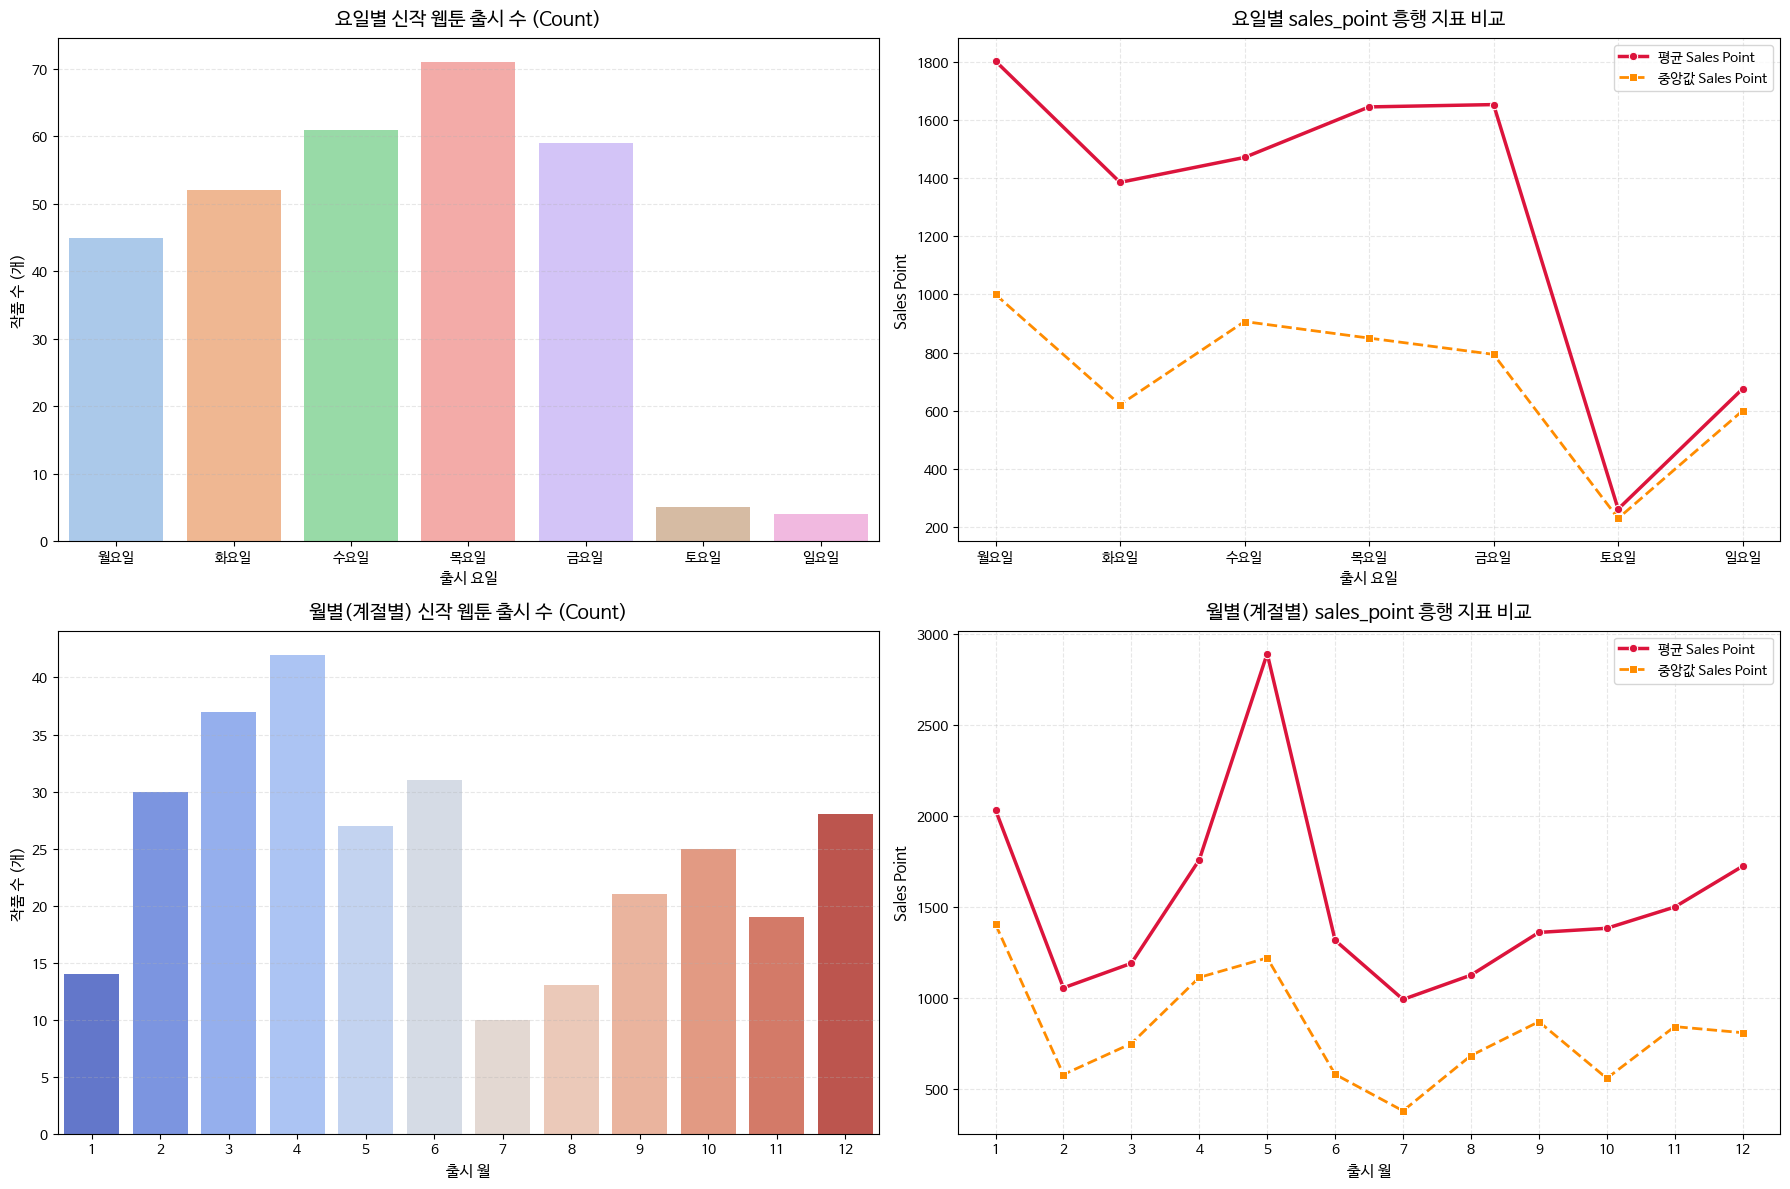

= = = = = = = = = = = = = = = = = = = = = = = = = 
[1] 요일별 웹툰 출시 및 흥행 데이터 요약
pub_day_kor  count        mean  median
        월요일     45 1802.755556  1000.0
        화요일     52 1385.615385   621.0
        수요일     61 1471.442623   907.0
        목요일     71 1645.183099   850.0
        금요일     59 1653.186441   794.0
        토요일      5  261.800000   230.0
        일요일      4  675.750000   600.5
--------------------------------------------------
[2] 월별 웹툰 출시 및 흥행 데이터 요약
 pub_month  count        mean  median
         1     14 2032.214286  1404.5
         2     30 1055.700000   580.0
         3     37 1190.405405   750.0
         4     42 1758.333333  1113.0
         5     27 2890.407407  1220.0
         6     31 1316.548387   581.0
         7     10  992.100000   380.5
         8     13 1125.461538   684.0
         9     21 1359.952381   870.0
        10     25 1382.640000   559.0
        11     19 1499.368421   843.0
        12     28 1723.428571   809.5
= = = = = = = = = = = = = = = = = = = = =

In [13]:
df['pub_date'] = pd.to_datetime(df['pub_date'], errors='coerce')
df_cleaned = df.dropna(subset=['pub_date']).copy()

df_cleaned['pub_month'] = df_cleaned['pub_date'].dt.month
df_cleaned['pub_day_name'] = df_cleaned['pub_date'].dt.day_name()

day_kor_map = {
    'Monday': '월요일', 'Tuesday': '화요일', 'Wednesday': '수요일',
    'Thursday': '목요일', 'Friday': '금요일', 'Saturday': '토요일', 'Sunday': '일요일'
}
df_cleaned['pub_day_kor'] = df_cleaned['pub_day_name'].map(day_kor_map)

# 그래프 x축 정렬을 위한 순서 정의
kor_day_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']

day_summary = df_cleaned.groupby('pub_day_kor')['sales_point'].agg(
    count='count',
    mean='mean',
    median='median'
).reindex(kor_day_order).reset_index()


month_summary = df_cleaned.groupby('pub_month')['sales_point'].agg(
    count='count',
    mean='mean',
    median='median'
).reset_index()


fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))

sns.barplot(
    data=day_summary,
    x='pub_day_kor',
    y='count',
    palette='pastel',
    ax=axes[0, 0]
)
axes[0, 0].set_title('요일별 신작 웹툰 출시 수 (Count)', fontsize=14, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('출시 요일', fontsize=11)
axes[0, 0].set_ylabel('작품 수 (개)', fontsize=11)
axes[0, 0].grid(True, axis='y', alpha=0.3, linestyle='--')

# --- [1행 2열] 요일별 sales_point 화력 비교 (라인 차트) ---
sns.lineplot(data=day_summary, x='pub_day_kor', y='mean', marker='o', color='crimson', linewidth=2.5, label='평균 Sales Point', ax=axes[0, 1])
sns.lineplot(data=day_summary, x='pub_day_kor', y='median', marker='s', color='darkorange', linewidth=2, linestyle='--', label='중앙값 Sales Point', ax=axes[0, 1])
axes[0, 1].set_title('요일별 sales_point 흥행 지표 비교', fontsize=14, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('출시 요일', fontsize=11)
axes[0, 1].set_ylabel('Sales Point', fontsize=11)
axes[0, 1].grid(True, alpha=0.3, linestyle='--')
axes[0, 1].legend()

# --- [2행 1열] 월별 신작 출시 작품 수 (바 차트) ---
sns.barplot(
    data=month_summary,
    x='pub_month',
    y='count',
    palette='coolwarm',
    ax=axes[1, 0]
)
axes[1, 0].set_title('월별(계절별) 신작 웹툰 출시 수 (Count)', fontsize=14, fontweight='bold', pad=10)
axes[1, 0].set_xlabel('출시 월', fontsize=11)
axes[1, 0].set_ylabel('작품 수 (개)', fontsize=11)
axes[1, 0].grid(True, axis='y', alpha=0.3, linestyle='--')

# --- [2행 2열] 월별 sales_point 화력 비교 (라인 차트) ---
# x축 눈금을 1월부터 12월까지 명확하게 고정하기 위해 range 설정
x_month_indices = range(len(month_summary))

sns.lineplot(data=month_summary, x=x_month_indices, y='mean', marker='o', color='crimson', linewidth=2.5, label='평균 Sales Point', ax=axes[1, 1])
sns.lineplot(data=month_summary, x=x_month_indices, y='median', marker='s', color='darkorange', linewidth=2, linestyle='--', label='중앙값 Sales Point', ax=axes[1, 1])
axes[1, 1].set_title('월별(계절별) sales_point 흥행 지표 비교', fontsize=14, fontweight='bold', pad=10)
axes[1, 1].set_xlabel('출시 월', fontsize=11)
axes[1, 1].set_ylabel('Sales Point', fontsize=11)
axes[1, 1].set_xticks(x_month_indices)
axes[1, 1].set_xticklabels(month_summary['pub_month'].astype(int))
axes[1, 1].grid(True, alpha=0.3, linestyle='--')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("= " * 25)
print("[1] 요일별 웹툰 출시 및 흥행 데이터 요약")
print(day_summary.to_string(index=False))
print("-" * 50)
print("[2] 월별 웹툰 출시 및 흥행 데이터 요약")
print(month_summary.to_string(index=False))
print("= " * 25)

평일이 전반적으로 많은 것을 보아 웹툰은 출퇴근 및 등하교를 하면서 많이 보는 것으로 유추된다.

# 3. 장르와 포스터 감성의 Sales Point 관계 분석

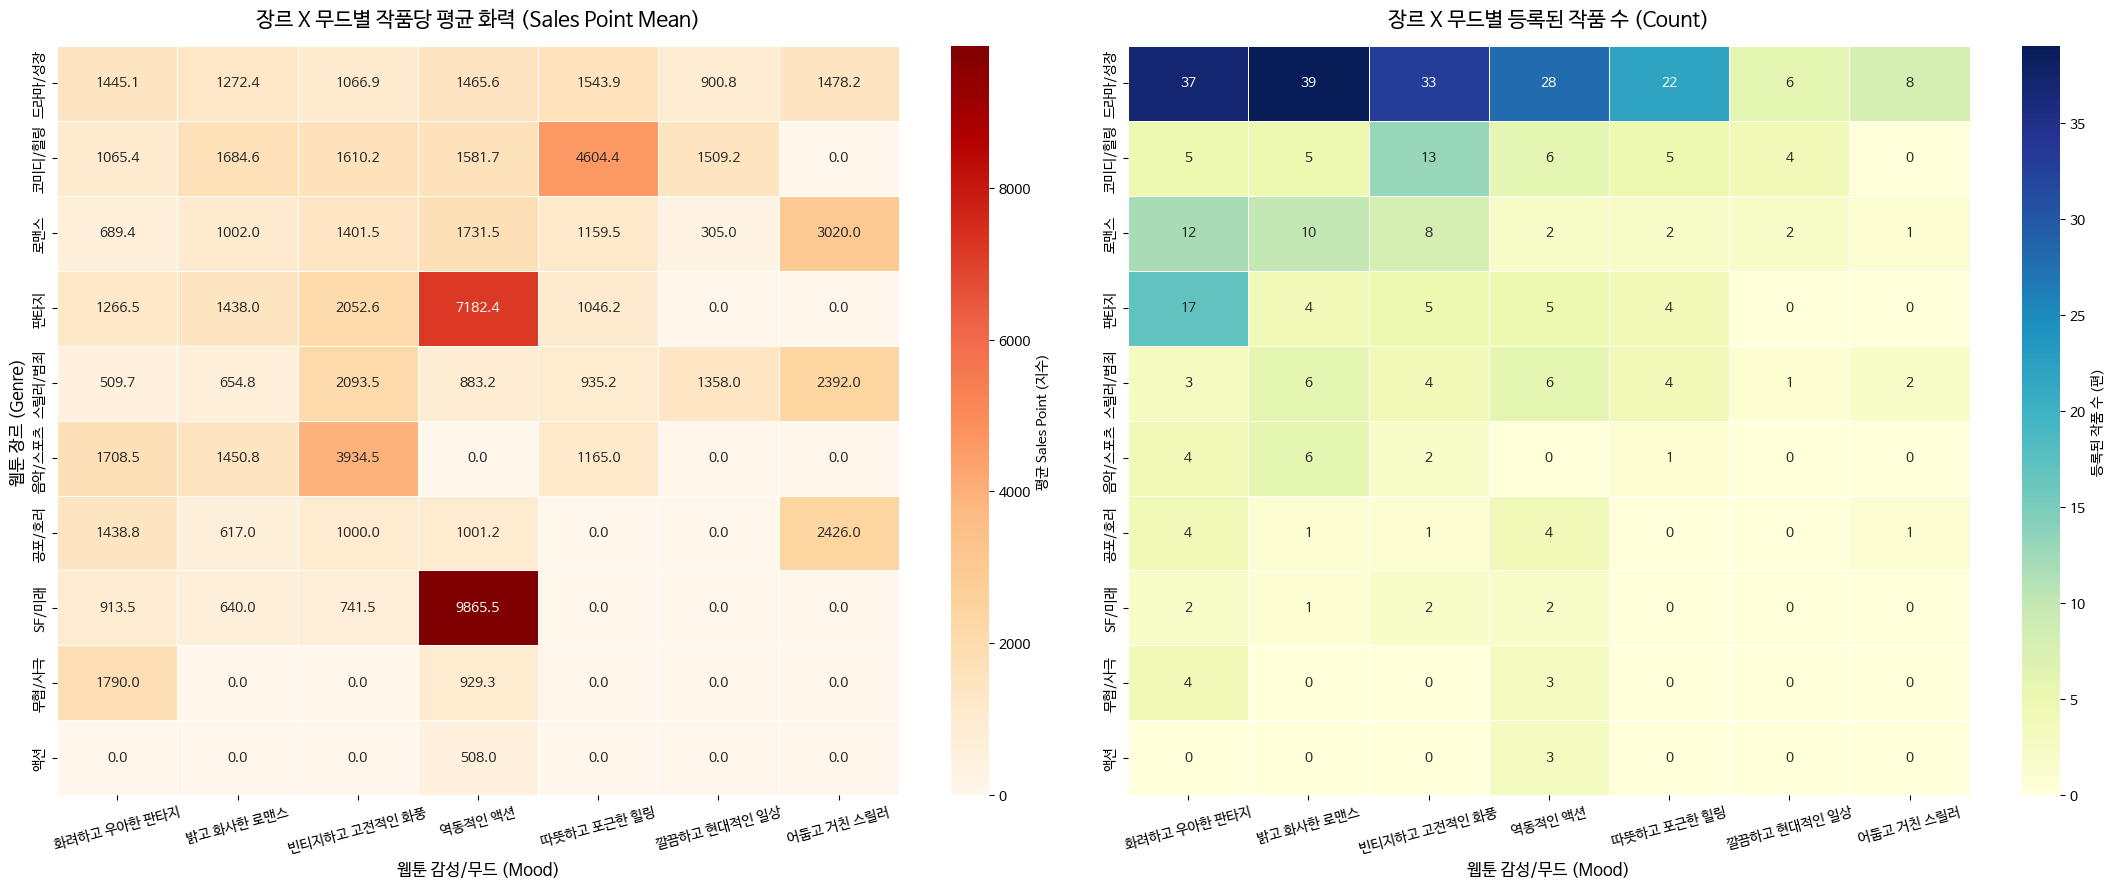


=== [작품 수가 2편 이상인 조합 중, 평균 Sales Point 탑 10 꿀조합] ===
genre_list      mood_kor  작품수   평균화력    중앙값
     SF/미래       역동적인 액션    2 9865.5 9865.5
       판타지       역동적인 액션    5 7182.4 4967.0
    코미디/힐링   따뜻하고 포근한 힐링    5 4604.4 1185.0
    음악/스포츠 빈티지하고 고전적인 화풍    2 3934.5 3934.5
    스릴러/범죄    어둡고 거친 스릴러    2 2392.0 2392.0
    스릴러/범죄 빈티지하고 고전적인 화풍    4 2093.5 2384.0
       판타지 빈티지하고 고전적인 화풍    5 2052.6 2180.0
     무협/사극  화려하고 우아한 판타지    4 1790.0  952.5
       로맨스       역동적인 액션    2 1731.5 1731.5
    음악/스포츠  화려하고 우아한 판타지    4 1708.5 1595.5


In [10]:
top_genres = df_genre_exploded['genre_list'].value_counts().head(10).index
top_moods = df_genre_exploded['mood_kor'].value_counts().head(7).index

# 상위 장르 및 무드 필터링
df_filtered_comb = df_genre_exploded[
    (df_genre_exploded['genre_list'].isin(top_genres)) &
    (df_genre_exploded['mood_kor'].isin(top_moods))
]

# 2. 피벗 테이블(Pivot Table)을 이용해 '작품 수'와 'sales_point 평균/중앙값'을 동시에 계산
pivot_analysis = df_filtered_comb.pivot_table(
    index='genre_list',
    columns='mood_kor',
    values='sales_point',
    aggfunc=['count', 'mean', 'median']
)

# 시각화 가독성을 위해 상위 장르/무드 순서로 행과 열 정렬
pivot_count = pivot_analysis['count'].loc[top_genres, top_moods].fillna(0).astype(int)
pivot_mean = pivot_analysis['mean'].loc[top_genres, top_moods].fillna(0)
pivot_median = pivot_analysis['median'].loc[top_genres, top_moods].fillna(0)


# 3. 히트맵 시각화 (좌: 작품당 평균 화력 / 우: 실제 작품 수)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22, 9))

# [왼쪽 히트맵] 장르 X 무드별 '작품당 평균 Sales Point'
sns.heatmap(
    pivot_mean,
    annot=True,
    fmt='.1f',           # 소수점 첫째자리까지 표시
    cmap='OrRd',         # 화력을 상징하는 오렌지-레드 컬러맵
    linewidths=0.5,
    ax=axes[0],
    cbar_kws={'label': '평균 Sales Point (지수)'}
)
axes[0].set_title('장르 X 무드별 작품당 평균 화력 (Sales Point Mean)', fontsize=15, fontweight='bold', pad=15)
axes[0].set_xlabel('웹툰 감성/무드 (Mood)', fontsize=12)
axes[0].set_ylabel('웹툰 장르 (Genre)', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)

# [오른쪽 히트맵] 장르 X 무드별 '등록된 실제 작품 수'
sns.heatmap(
    pivot_count,
    annot=True,
    fmt='d',             # 정수형 포맷
    cmap='YlGnBu',       # 기존에 쓰던 옐로우-그린-블루 컬러맵
    linewidths=0.5,
    ax=axes[1],
    cbar_kws={'label': '등록된 작품 수 (편)'}
)
axes[1].set_title('장르 X 무드별 등록된 작품 수 (Count)', fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel('웹툰 감성/무드 (Mood)', fontsize=12)
axes[1].set_ylabel('', fontsize=12) # y축 중복 제거
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()


# 4. 추가 꿀팁: 텍스트 형태로 '대박 꿀조합 탑 10' 바로 확인하기
print("\n=== [작품 수가 2편 이상인 조합 중, 평균 Sales Point 탑 10 꿀조합] ===")
comb_summary = df_filtered_comb.groupby(['genre_list', 'mood_kor'])['sales_point'].agg(
    작품수='count',
    평균화력='mean',
    중앙값='median'
).reset_index()

# 샘플 수가 너무 적어 튀는 조합을 방지하기 위해 최소 작품 수 2편 이상 필터링
lucrative_comb = comb_summary[comb_summary['작품수'] >= 2].sort_values(by='평균화력', ascending=False).head(10)
print(lucrative_comb.to_string(index=False))

전반적으로 역동적인 액셔이나, 따뜻하고 포근한 힐링의 작품이 잘 팔림.

나의 인사이트인데, 웹툰을 보는 이유가 힐링이거나, 아니면 도파민 충족인데

표지가 큰 영향을 준다고 본다. 왜냐하면 첫인상이 중요하다. 그래서 도파민 충족과는 역동적인 액션 부분을 선택하고, 힐링을 위한 사람들은 따뜻하고 포근한 힐링을 선호해서 이런 결과가 나오는 것이 아닌가 생각한다.

도파민(Dopamine) 스파이크형 소비 ➔ [역동적인 액션]

유저들은 현실의 지루함이나 스트레스를 날려버릴 강력한 자극과 대리 만족을 원해.

이때 표지(Thumbnail)에서 거친 선화, 화려한 이펙트, 역동적인 구도가 보이면 뇌는 직관적으로 "여기서 내 도파민을 채울 수 있겠다"라고 판단하고 탭(sales_point 상승)하게 되는 거지.
"
세로토닌(Serotonin) & 옥시토신 안형 소비 ➔ [따뜻하고 포근한 힐링]

반대로 지친 하루를 마치고 위로와 안정을 찾으려는 유저들은 자극적인 걸 피하고 싶어 해.

표지에서 파스텔톤의 따뜻한 색감, 둥글둥글하고 무해한 캐릭터 화풍이 보이면 뇌가 편안함을 느끼며 "이건 안전한 대피소야"라고 인식하고 지갑을 여는 거야.